✗ Error: The file 'dataset.csv' was not found.
Please make sure you have uploaded the file and the filename matches.

--- Running with a demo dataset instead ---

PHASE 2: DATASET EXPLORATION

--- First 5 Rows of the Dataset ---
                                                text sentiment
0  I absolutely love this product! It works perfe...  positive
1  This is the worst service ever... 10/10 would ...  negative
2      It is okay, nothing special but does the job.   neutral
3  Wow, amazing quality! Fast shipping too!!! #happy  positive
4   I hate waiting for so long. Very disappointed. 😡  negative

--- Dataset Dimensions ---
Total Rows: 6
Total Columns: 2

--- Column Names & Data Types ---
text         object
sentiment    object
dtype: object

--- Missing (Null) Values Count per Column ---
text         1
sentiment    0
dtype: int64

--- Visualizing Class Distribution for 'sentiment' ---
Class Distribution:
sentiment
positive    2
negative    2
neutral     2
Name: count, dtype: int64


/tmp/ipykernel_1270/3470201010.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=LABEL_COLUMN, palette='viridis')


✓ Distribution plot saved as 'sentiment_distribution.png'


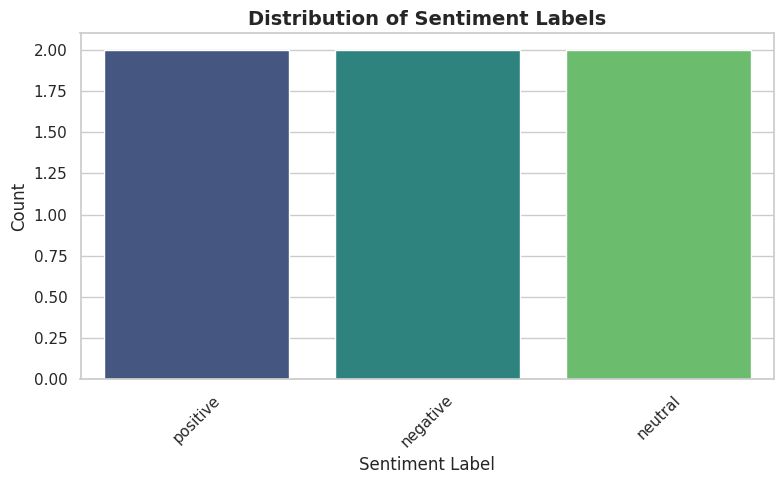


PHASE 3: DATA CLEANING
Cleaning the 'text' column...

--- Cleaning Comparison (Original vs. Cleaned) ---
                                                text  \
0  I absolutely love this product! It works perfe...   
1  This is the worst service ever... 10/10 would ...   
2      It is okay, nothing special but does the job.   
3  Wow, amazing quality! Fast shipping too!!! #happy   
4   I hate waiting for so long. Very disappointed. 😡   

                                        cleaned_text  
0  i absolutely love this product it works perfectly  
1  this is the worst service ever would not recom...  
2        it is okay nothing special but does the job  
3        wow amazing quality fast shipping too happy  
4       i hate waiting for so long very disappointed  

Rows empty after cleaning (will be dropped): 1

✓ Cleaned dataset saved successfully as 'cleaned_dataset.csv'
Final clean dataset shape: (5, 3)


/tmp/ipykernel_1270/3470201010.py:149: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['cleaned_text'].replace('', np.nan, inplace=True)


In [ ]:
# -*- coding: utf-8 -*-
"""
Sentiment Analysis: Phase 2 (Dataset Exploration) & Phase 3 (Data Cleaning)
This script is designed to run in Google Colab.
"""

# ==============================================================================
# STEP 1: IMPORT NECESSARY LIBRARIES
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

# Set the style for visualizations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [8, 5]

# ==============================================================================
# STEP 2: LOAD THE DATASET
# ==============================================================================
# Replace 'dataset.csv' with the actual filename of your uploaded CSV file.
FILE_PATH = 'dataset.csv'

try:
    # Load the CSV file into a Pandas DataFrame
    df = pd.read_csv(FILE_PATH)
    print("✓ Dataset loaded successfully!")
except FileNotFoundError:
    print(f"✗ Error: The file '{FILE_PATH}' was not found.")
    print("Please make sure you have uploaded the file and the filename matches.")
    # Creating a dummy dataset so the rest of the code can still run as a demo
    print("\n--- Running with a demo dataset instead ---")
    demo_data = {
        'text': [
            "I absolutely love this product! It works perfectly. https://example.com",
            "This is the worst service ever... 10/10 would NOT recommend!!",
            "It is okay, nothing special but does the job.",
            "Wow, amazing quality! Fast shipping too!!! #happy",
            "I hate waiting for so long. Very disappointed. 😡",
            None
        ],
        'sentiment': ['positive', 'negative', 'neutral', 'positive', 'negative', 'neutral']
    }
    df = pd.DataFrame(demo_data)

# ==============================================================================
# PHASE 2: DATASET EXPLORATION
# ==============================================================================
print("\n" + "="*50)
print("PHASE 2: DATASET EXPLORATION")
print("="*50)

# 1. Display the first 5 rows
print("\n--- First 5 Rows of the Dataset ---")
print(df.head())

# 2. Get the dimensions (rows and columns count)
rows, cols = df.shape
print(f"\n--- Dataset Dimensions ---")
print(f"Total Rows: {rows}")
print(f"Total Columns: {cols}")

# 3. Print the column names and data types
print("\n--- Column Names & Data Types ---")
print(df.dtypes)

# 4. Check for null (missing) values in the dataset
print("\n--- Missing (Null) Values Count per Column ---")
print(df.isnull().sum())

# 5. Visualize the label/class distribution
# Note: Replace 'sentiment' with the actual column name of your labels/classes
LABEL_COLUMN = 'sentiment'

if LABEL_COLUMN in df.columns:
    print(f"\n--- Visualizing Class Distribution for '{LABEL_COLUMN}' ---")

    # Calculate value counts
    class_counts = df[LABEL_COLUMN].value_counts()
    print("Class Distribution:")
    print(class_counts)

    # Create the plot
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=LABEL_COLUMN, palette='viridis')
    plt.title('Distribution of Sentiment Labels', fontsize=14, fontweight='bold')
    plt.xlabel('Sentiment Label', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Save the plot as an image in Colab workspace
    plt.savefig('sentiment_distribution.png')
    print("✓ Distribution plot saved as 'sentiment_distribution.png'")
    plt.show()
else:
    print(f"\n⚠ Warning: Column '{LABEL_COLUMN}' not found. Skipping visualization.")

# ==============================================================================
# PHASE 3: DATA CLEANING
# ==============================================================================
print("\n" + "="*50)
print("PHASE 3: DATA CLEANING")
print("="*50)

# Define the text column name (Replace 'text' with your dataset's text column name)
TEXT_COLUMN = 'text'

# Helper function to clean text data
def clean_text(text):
    # Handle null or float values in text column
    if not isinstance(text, str):
        return ""

    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove URLs (e.g., http://... or https://...)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # 3. Remove HTML tags (common in scraped datasets)
    text = re.sub(r'<.*?>', '', text)

    # 4. Remove numbers/digits
    text = re.sub(r'\d+', '', text)

    # 5. Remove punctuation and special characters (keep only lowercase letters and spaces)
    text = re.sub(r'[^a-z\s]', '', text)

    # 6. Remove extra whitespaces and trim leading/trailing spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

if TEXT_COLUMN in df.columns:
    print(f"Cleaning the '{TEXT_COLUMN}' column...")

    # Create a new column for cleaned text so we keep the original text intact
    df['cleaned_text'] = df[TEXT_COLUMN].apply(clean_text)

    # Display the comparison between original and cleaned text
    print("\n--- Cleaning Comparison (Original vs. Cleaned) ---")
    print(df[[TEXT_COLUMN, 'cleaned_text']].head())

    # Drop rows that ended up empty after cleaning
    df['cleaned_text'].replace('', np.nan, inplace=True)
    null_after_cleaning = df['cleaned_text'].isnull().sum()
    print(f"\nRows empty after cleaning (will be dropped): {null_after_cleaning}")
    df.dropna(subset=['cleaned_text'], inplace=True)

    # Save the cleaned dataset to a new CSV file
    df.to_csv('cleaned_dataset.csv', index=False)
    print("\n✓ Cleaned dataset saved successfully as 'cleaned_dataset.csv'")
    print(f"Final clean dataset shape: {df.shape}")
else:
    print(f"✗ Error: Text column '{TEXT_COLUMN}' not found in the dataset.")
